## Hyperparameter Tuning: Random Forest CLFS

In [6]:
from pathlib import Path
import sys

sys.path.append(str(Path.cwd().parents[1]))
from src.utils import plot_roc_curve, optimized_search, conf_matrix

In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from skopt.space import Categorical, Integer

import pandas as pd
import numpy as np

df = pd.read_csv('../../data/processed/creditcard-processed.csv')
df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


## Model Tuning using Bayesian Search

In [3]:
X = df.drop('Class', axis=1)
y = df.Class

xtrain, xtest, ytrain, ytest = train_test_split(
    X, y, random_state=42, stratify=y
)

In [ ]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('rfs', RandomForestClassifier(random_state=42))
])

params_grid = {
    'rfs__class_weight' : Categorical(['balanced', 'balanced_subsample']),
    'rfs__n_estimators' : Integer(100, 300),
    'rfs__max_depth' : Categorical([10, 20, 30, None]),
    'rfs__max_features' : Categorical(['sqrt', 'log2'])
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

ypred, model = optimized_search(
    pipe,
    cv,
    params_grid,
    xtrain, ytrain, xtest, ytest,
    'average_precision'
)

Best Hyperparameters: OrderedDict({'rfs__class_weight': 'balanced', 'rfs__max_depth': 20, 'rfs__max_features': 'sqrt', 'rfs__n_estimators': 299})


AttributeError: 'BayesSearchCV' object has no attribute 'best_score'

## Training with the Best Hyperparameters

In [ ]:
"""
    we will be using the best model estimators from the Bayessian Search
"""

scaler = StandardScaler()
xtrain_scaled = scaler.fit_transform(xtrain)
xtest_scaled = scaler.transform(xtest)

rfs = RandomForestClassifier(class_weight='balanced', 
                             max_depth=20, max_features='sqrt', n_estimators=299)

rfs.fit(xtrain_scaled, ytrain)
yhat = rfs.predict(xtest_scaled)
yprob = rfs.predict_proba(xtest_scaled)[:,1]

accuracy = accuracy_score(ytest, yhat)
roc_score = roc_auc_score(ytest, yprob)

rfs_metrics = pd.DataFrame({
    'Accuracy' : [accuracy],
    'ROC Score' : [roc_score]
})

print(rfs_metrics)

   Accuracy  ROC Score
0  0.999478   0.971802


## ROC AUC Score

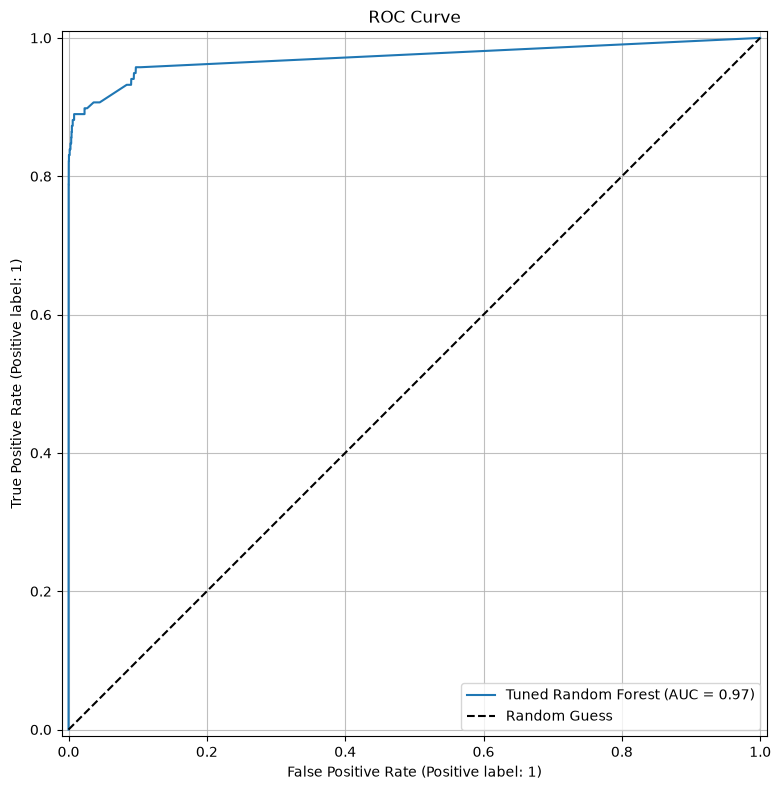

In [7]:
plot_roc_curve(rfs, xtest_scaled, ytest, 'Tuned Random Forest')

## Confusion Matrix

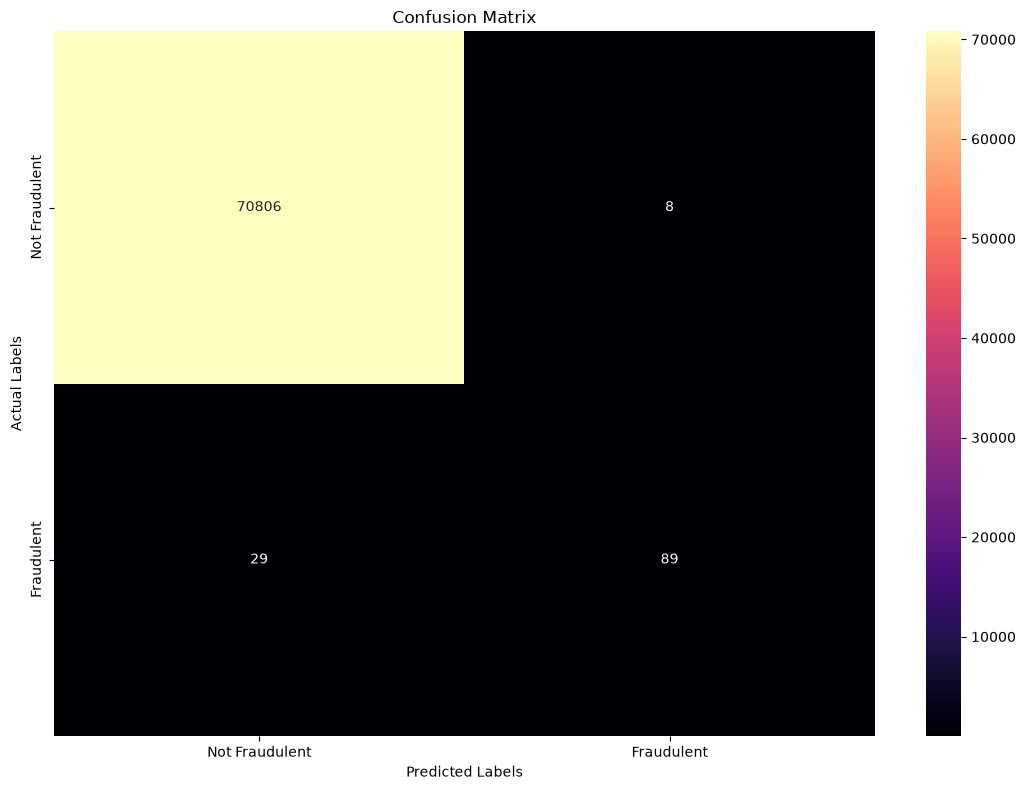

In [8]:
conf_matrix(ytest, yhat, ['Not Fraudulent', 'Fraudulent'])

## Classification Report

In [9]:
print(classification_report(ytest, yhat))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     70814
           1       0.92      0.75      0.83       118

    accuracy                           1.00     70932
   macro avg       0.96      0.88      0.91     70932
weighted avg       1.00      1.00      1.00     70932



# SMOTE + Tuned Random Forest Classifier

In [12]:
smote = SMOTE(random_state=42)

xtrain_smote, ytrain_smote = smote.fit_resample(xtrain_scaled, ytrain)

rfs = RandomForestClassifier(max_depth=20, max_features='sqrt', n_estimators=299)
rfs.fit(xtrain_smote, ytrain_smote)

yhat_smote = rfs.predict(xtest_scaled)
yprob_smote = rfs.predict_proba(xtest_scaled)[:,1]

smote_acc = accuracy_score(ytest, yhat_smote)
smote_roc = roc_auc_score(ytest, yprob_smote)

smote_rfs = pd.DataFrame({
    'Smote Accuracy' : [smote_acc],
    'Smote ROC' : [smote_roc]
})

print(smote_rfs)
print(classification_report(ytest, yhat_smote))

   Smote Accuracy  Smote ROC
0        0.999366   0.976822
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     70814
           1       0.83      0.77      0.80       118

    accuracy                           1.00     70932
   macro avg       0.92      0.89      0.90     70932
weighted avg       1.00      1.00      1.00     70932



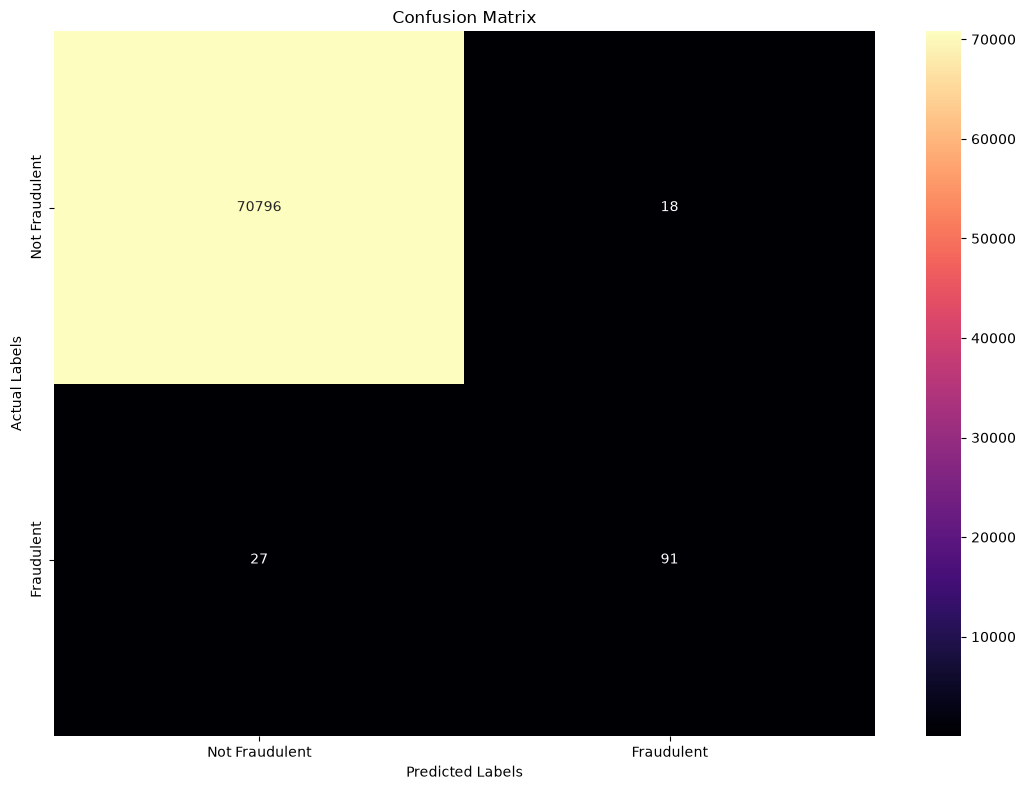

In [14]:
# smote + rfs confusion matrix
conf_matrix(ytest, yhat_smote, ['Not Fraudulent', 'Fraudulent'])

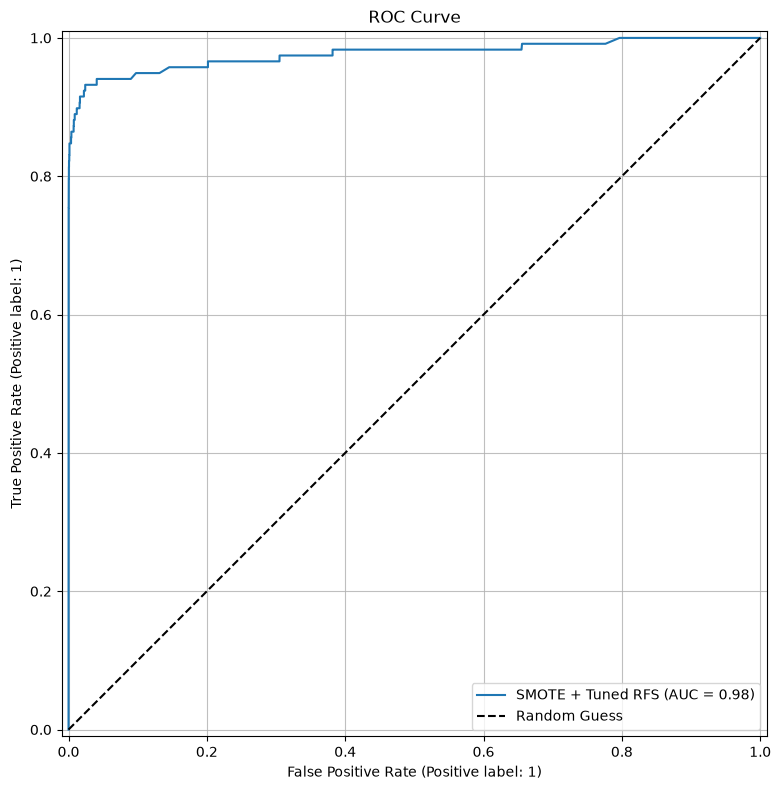

In [16]:
# roc curve with SMOTE sampling
plot_roc_curve(rfs, xtest_scaled, ytest, 'SMOTE + Tuned RFS')